------------

Nội dung mà nhóm đã triển khai trong bài
-----

Mục tiêu của đồ án này là xây dựng được model:
 1. Model `KMEANS`
 2. Model `GMM (Gaussian Mixture)`

# II.CLUSTERING

## A .KMEANS

### 1. Làm sạch dữ liệu & Khai phá dữ liệu

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# tải dữ liệu lên VSCODE
test= pd.read_csv('test.csv')
train= pd.read_csv('train.csv')

# nói 2 dữ liệu lại thành 1 bộ
df = pd.concat([test,train], axis= 0,ignore_index=True)

In [3]:
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
129876,103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
129877,103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
129878,103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


Kiểm tra thông tin tổng quan của bộ dữ liệu:
- Bộ dữ liệu có *25* cột ( *19: int, 1: float, 5: string* ) với *129880* dòng dữ liệu
- Tại cột `Arrival Delay in Minutes` có các giá trị bị NaN

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  str    
 3   Customer Type                      129880 non-null  str    
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  str    
 6   Class                              129880 non-null  str    
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      129880 non-null

In [5]:
#Kiểm tra và xóa các dòng dữ liệu bị lặp lại 
print("Số lượng trùng lập của bộ dữ liệu:",df.duplicated().sum())
df.drop_duplicates(inplace=True)

Số lượng trùng lập của bộ dữ liệu: 0


In [6]:
# Xóa 2 cột Unnamed: 0 và ID
drop_cols= ['Unnamed: 0','id'] 
df= df.drop(columns= drop_cols, axis=0)

Tiến hành kiểm tra các giá trị của bộ `df`

In [7]:
df.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


Tổng hợp thông tin và các bước mà nhóm em đã khám phá dữ liệu của bộ train: cụ thể là khám phá tỉ lệ của `satisfied` và `other` trong `Outlier` và bộ `train`  

 | Description | Percent |
 |-----------------:|----------------:|
 | Tỉ lệ dữ liệu outlier so với tập train | 0.9971% |
 | Tỉ lệ dữ liệu 'satisfied' trong outlier | 76.9884% |
 | Tỉ lệ dữ liệu nhóm còn lại trong outlier | 23.0116% |
 | Tỉ lệ outlier nằm trong toàn bộ nhóm 'satisfied' | 1.7669% |
 | Tỉ lệ outlier nằm trong toàn bộ nhóm còn lại | 1.3573% |

Tuy tỉ lệ của dữ liệu `outlier` không cao những tụi em vẫn sẽ giữ chúng lại thay vì là xóa bỏ

In [8]:
train = df.copy()

In [9]:
upper_bound = train['Flight Distance'].quantile(0.99)
outlier_shape= train[train['Flight Distance'] > upper_bound].shape
train_shape= train.shape
train_satisfied_shape = train[train['satisfaction'] == 'satisfied'].shape
train_dissatisfied_shape = train[train['satisfaction'] != 'satisfied'].shape

In [10]:
x= outlier_shape[0]
y= train_shape[0]
outlier_percen = (x/y)*100
print(f"Tỉ lệ dữ liệu outlier so với bộ train: {outlier_percen:.4f}")

Tỉ lệ dữ liệu outlier so với bộ train: 0.9971


In [11]:
x= train[(train['Flight Distance'] > upper_bound )& (train['satisfaction'] != 'satisfied')].shape
y= train[(train['Flight Distance'] > upper_bound )& (train['satisfaction'] == 'satisfied')].shape

neural_or_dissatisfied= (x[0]/(x[0]+y[0])*100)
satisfied_percen = (y[0]/(x[0]+y[0])*100)

In [12]:
print(f"Tỉ lệ dữ liệu satisfaction trong outlier : {satisfied_percen:.4f}") 
print(f"Tỉ lệ dữ liệu neural or dissatisfied trong outlier: {neural_or_dissatisfied:.4f}")

Tỉ lệ dữ liệu satisfaction trong outlier : 76.9884
Tỉ lệ dữ liệu neural or dissatisfied trong outlier: 23.0116


In [13]:
satisfied_outlier_train = (y[0]/train_satisfied_shape[0])*100
dissatisfied_outlier_train = (y[0]/train_dissatisfied_shape[0])*100

print(f"Tỉ lệ dữ liệu satisfaction của outlier trong toàn bộ train: {satisfied_outlier_train:.4f}")
print(f"Tỉ lệ dữ liệu nhóm còn lại của outlier trong toàn bộ train: {dissatisfied_outlier_train:.4f}")

Tỉ lệ dữ liệu satisfaction của outlier trong toàn bộ train: 1.7669
Tỉ lệ dữ liệu nhóm còn lại của outlier trong toàn bộ train: 1.3573


Kiểm tra số lượng và thông tin của giá trị trong từng cột  

In [14]:
df_col = train.columns
for col_name in df_col[0:5]:
    unique_values = train[col_name].unique()
    print('------------------------')
    print(f"{col_name}: {unique_values}")


------------------------
Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
------------------------
Customer Type: <StringArray>
['Loyal Customer', 'disloyal Customer']
Length: 2, dtype: str
------------------------
Age: [52 36 20 44 49 16 77 43 47 46 33 60 50 31 55 25 30 62 24 22 51 56 41 53
 12 39 32 40 42 28 59 58 27 67 70 66 19 69 35 54 26 61 21 37 45 38  7 34
 17 15 48 13 11 29  8 18 23 65 57 80 64  9 14 68 10 79 63 73 74 71 72 76
 78 75 85]
------------------------
Type of Travel: <StringArray>
['Business travel', 'Personal Travel']
Length: 2, dtype: str
------------------------
Class: <StringArray>
['Eco', 'Business', 'Eco Plus']
Length: 3, dtype: str


Tạo 2 biểu đồ `Boxplot` và `Histplot` để quan sát độ phân tán và giá trị phân phối của dữ liệu

Thông qua biểu đồ chúng ta thấy được trực quan hơn dữ liệu lệch phải của 3 cột `Arrival Delay in Minutes`, `Departure Delay in Minutes`, `Flight Distance`

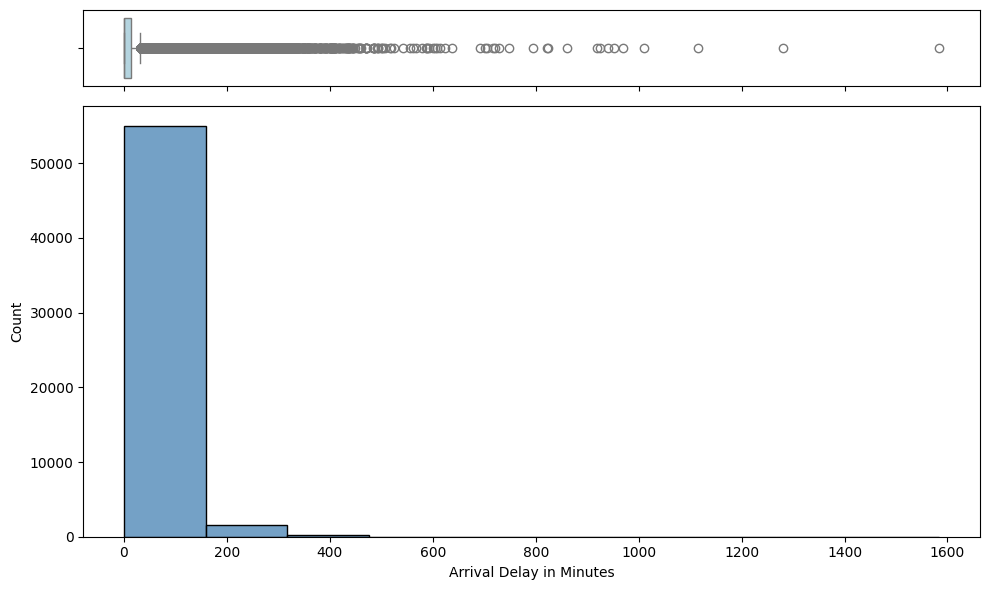

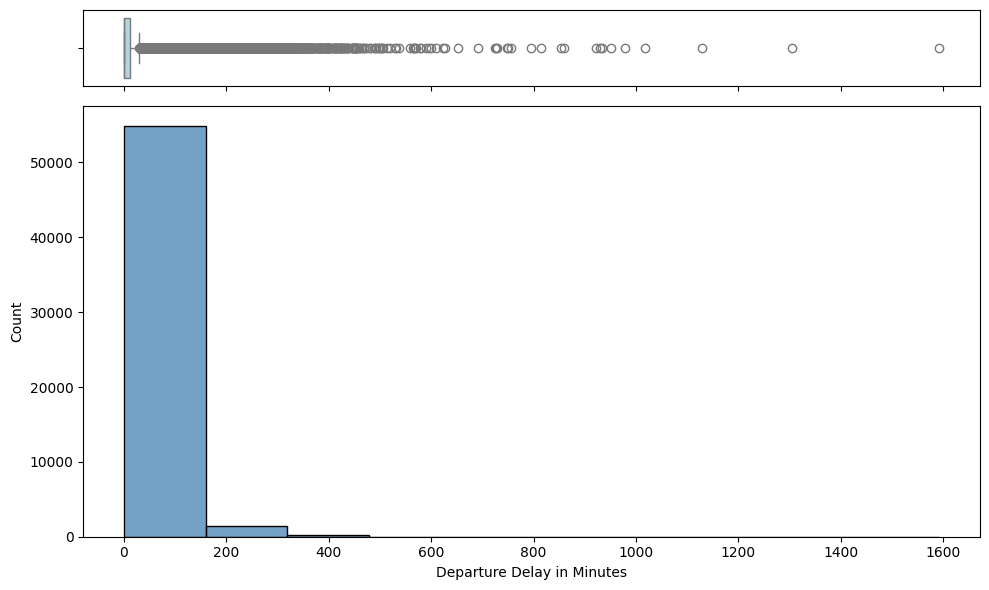

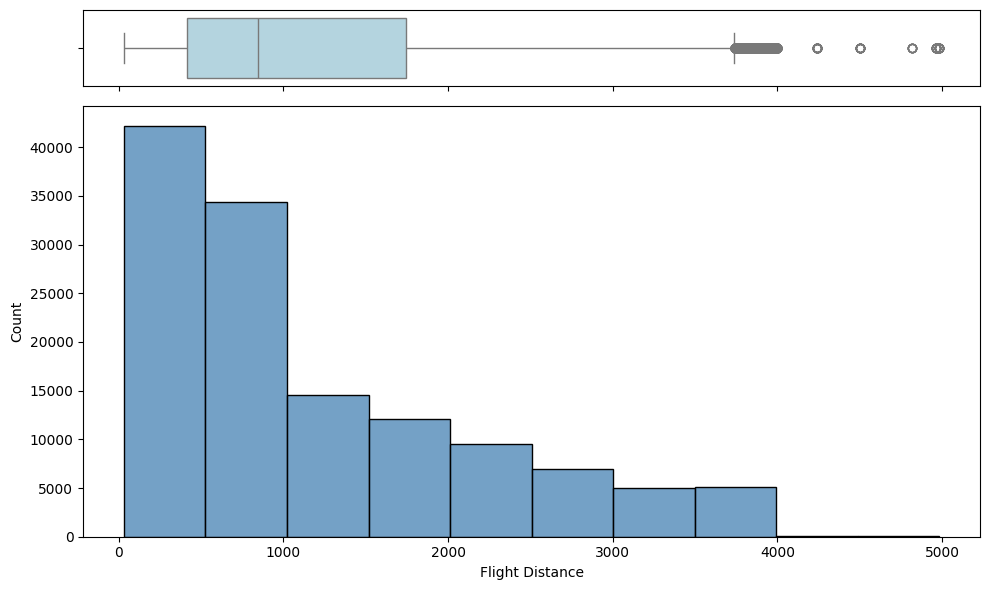

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ['Arrival Delay in Minutes', 'Departure Delay in Minutes','Flight Distance']
for col in cols_to_plot:
    filtered_train = train[train[col] > 0] # do có quá nhiều dữ liệu ở giá trị 0 nên em sẽ loại bỏ 0 để dễ nhìn các giá trị còn lại
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))
    sns.boxplot(x=train[col], ax=ax_box, color='lightblue')
    sns.histplot(data=filtered_train, x=col, ax=ax_hist, bins=10, color='steelblue')
    plt.tight_layout()
    plt.show()

Xử lý các giá trị bị NaN bằng phương pháp `Meadian` do bộ dữ liệu bị lệch rất nặng ở cột `Arrival Delay in Minutes`  


In [16]:
from sklearn.impute import SimpleImputer
df_trans = train[['Arrival Delay in Minutes']]
imp_median = SimpleImputer(missing_values=np.nan,strategy='median')
imp_median.fit(df_trans)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [17]:
# Chuyển output trên về lại dataframe
df_trans = pd.DataFrame(imp_median.transform(df_trans),
                          columns=df_trans.columns,
                          index=df_trans.index)
train.update(df_trans)

Tại đây nhóm em tạo thêm một bộ dữ liệu là `df_second` dùng để thực hiện các biện pháp xử lý dữ liệu song song với bộ train

In [18]:
df_second = train.copy()
df_second

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,Female,disloyal Customer,23,Business travel,Eco,192,2,1,2,3,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
129876,Male,Loyal Customer,49,Business travel,Business,2347,4,4,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
129877,Male,disloyal Customer,30,Business travel,Business,1995,1,1,1,3,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
129878,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,1,5,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied


Khi thực hiện xong phương pháp `Binning` - gom nhóm dữ liệu thành các nhóm để giải quyết các vấn đề Outlier
*** 
Cột `Age` nhóm em gom thành các 3 nhóm chính
1. `<20` đây là nhóm trẻ và vị thành niên
2. `20 - 59` đây là nhóm trung niên và ở đây tụi em sẽ chia nhỏ ra mỗi 10 năm là 1 nhóm
3. `>60` đây là nhóm tuổi già
***
Cột `Flight Distance` nhóm em sẽ chia theo Quantile (4 phân vị)
- 'Very Short', 'Short', 'Medium', 'Long'
***
Cột `Arrival Delay in Minutes` & `Departure Delay in Minutes` nhóm sẽ theo các tiêu chuẩn của ngành hàng không để chia thành 4 nhóm
- 'On time', 'Slightly delayed', 'Delayed', 'Very delayed'

In [19]:
# chia theo nhóm tuổi
bins_age = [0, 19, 29, 39, 49, 59, 120]
labels_age = ['<20', '20-29', '30-39', '40-49', '50-59', '60+']
df_second['Age'] = pd.cut(df_second['Age'],bins= bins_age, labels= labels_age).astype(str)

# chia theo Quantile (4 nhóm bằng nhau về số lượng) cho khoảng cách bay của các chuyến.
labels_distance = ['Very Short', 'Short', 'Medium', 'Long']
df_second['Flight Distance'] = pd.qcut(df_second['Flight Distance'],q=4,labels=labels_distance).astype(str)

# chia theo chuẩn của ngành hàng không
bins = [-1, 0, 15, 30, 57018] 
labels = ['On time', 'Slightly delayed', 'Delayed', 'Very delayed'] 
df_second['Arrival Delay in Minutes'] = pd.cut(df_second['Arrival Delay in Minutes'], bins=bins, labels=labels).astype(str)
df_second['Departure Delay in Minutes'] = pd.cut(df_second['Departure Delay in Minutes'], bins=bins, labels=labels).astype(str)

Dưới đây là 3 function mà em đã tạo, để phục vụ cho các mục địch xử lý dữ liệu cho bài
1. **remove_outlier_IQR**
    - Đây là hàm dùng để tìm kiếm các giá trị outlier bằng phương pháp IQR  
    - Dùng tính năng tứ phân vị để đưa ra giá trị IQR (Q3-Q1) sau đó tạo ra 2 giá trị là cận dưới (lower_bound) và cận trên (upper_bound)
    - dùng `.clip` để gán giá trị lower và upper cho các outlier vượt qua giá trị này, tránh việc xóa các giá trị outlier làm mất thông tin quan trọng  
---
2. **outlier_99_percen**
    - Đây cũng là 1 phương pháp tìm kiếm và gán các giá trị của outlier nhưng là ở phân vị thứ 99 (99%) của dữ liệu
    - Dùng `.quantile` kết hợp với biến `lower_percentile` và `upper_percentile` tại bài này thì chỉ áp dụng ở 2 cột là `Departure Delay in Minutes` và `Arrival Delay in Minutes` nên sẽ không có giá trị âm, em sẽ dùng lower là 0.0 và upper là 0.99 (99% dữ liệu).
    - Mục đích của hàm này là lấy 99% dữ liệu làm một bound, các giá trị vượt qua thì sẽ bị gán lại bằng chính giá trị của bound
---
3. **outliers_3percentile ($3\sigma$)**
    - Đây là hàm gán giá trị theo quy tắc $3\sigma$
    - Dùng chỉ số `mean` và `std` của cột dữ liệu cho ra 2 chốt chặn trên và dưới
    - Do dữ liệu ở 2 cột `Departure Delay in Minutes` và `Arrival Delay in Minutes` bị lệch phải nặng nên sẽ không khuyến khích dùng phương pháp này

In [20]:
# Hàm bỏ các giá trị outline bằng phương pháp IQR
def remove_outliers_IQR(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5* IQR
        print(f"Cột '{col}': Chặn dưới = {lower_bound:.2f}, Chặn trên = {upper_bound:.2f}")
        
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# Hàm gán các giá trị outlier về mức giới hạn phân vị (99%)
def outliers_99_percen(df, columns, lower_percentile=0.0, upper_percentile=0.99):
    for col in columns:
        lower_bound = df[col].quantile(lower_percentile)
        upper_bound = df[col].quantile(upper_percentile)
        print(f"Cột '{col}': Chặn dưới = {lower_bound:.2f}, Chặn trên (mốc {upper_percentile*100}%) = {upper_bound:.2f}")

        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# Hàm này giới hạn các giá trị theo quy tắc phân vị
def outliers_3percentile(df, columns):
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        upper_bound = mean + 3 * std
        lower_bound = mean - 3 * std
        print(f"Cột '{col}': Chặn dưới = {lower_bound:.2f}, Chặn trên = {upper_bound:.2f}")

        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

In [21]:
columns_to_cap = ['Departure Delay in Minutes', 'Arrival Delay in Minutes','Flight Distance']

In [ ]:
train = outliers_99_percen(train, columns=columns_to_cap, upper_percentile=0.99)


Cột 'Departure Delay in Minutes': Chặn dưới = 0.00, Chặn trên (mốc 99.0%) = 180.00
Cột 'Arrival Delay in Minutes': Chặn dưới = 0.00, Chặn trên (mốc 99.0%) = 182.00
Cột 'Flight Distance': Chặn dưới = 31.00, Chặn trên (mốc 99.0%) = 3884.00


In [ ]:
# train = remove_outliers_IQR(train,columns_to_cap)

In [24]:
# train = outliers_3percentile(train,columns_to_cap)

Tại đây em sẽ copy lại đoạn code tạo biểu đồ để trực quan giá trị của các cột đã được xử lý outlier.  

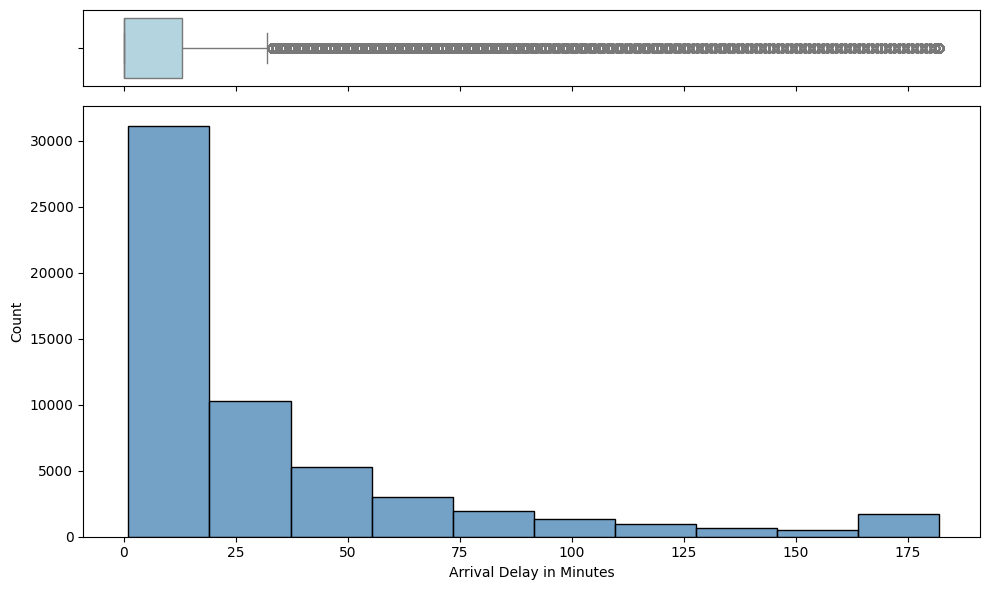

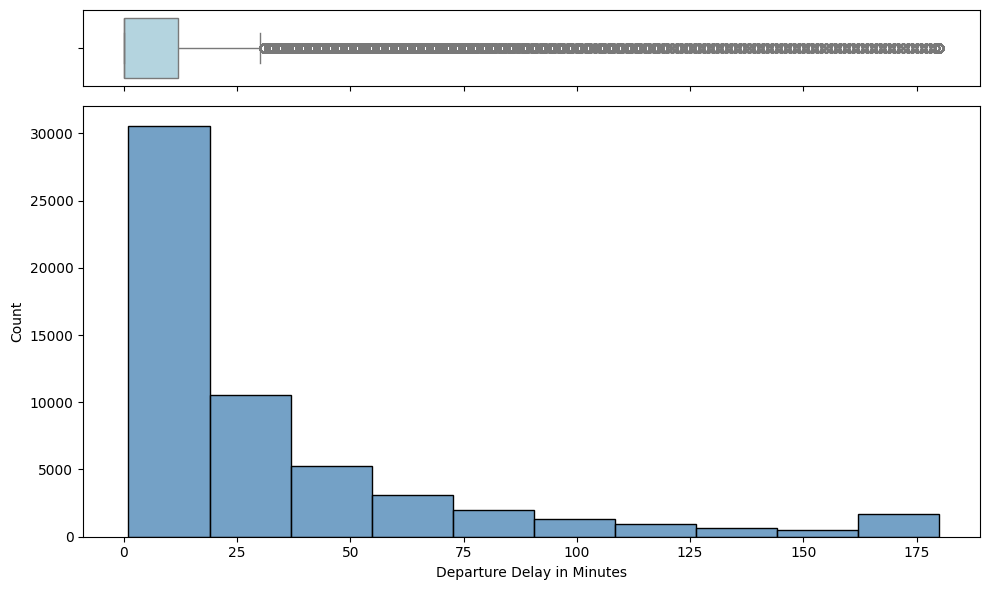

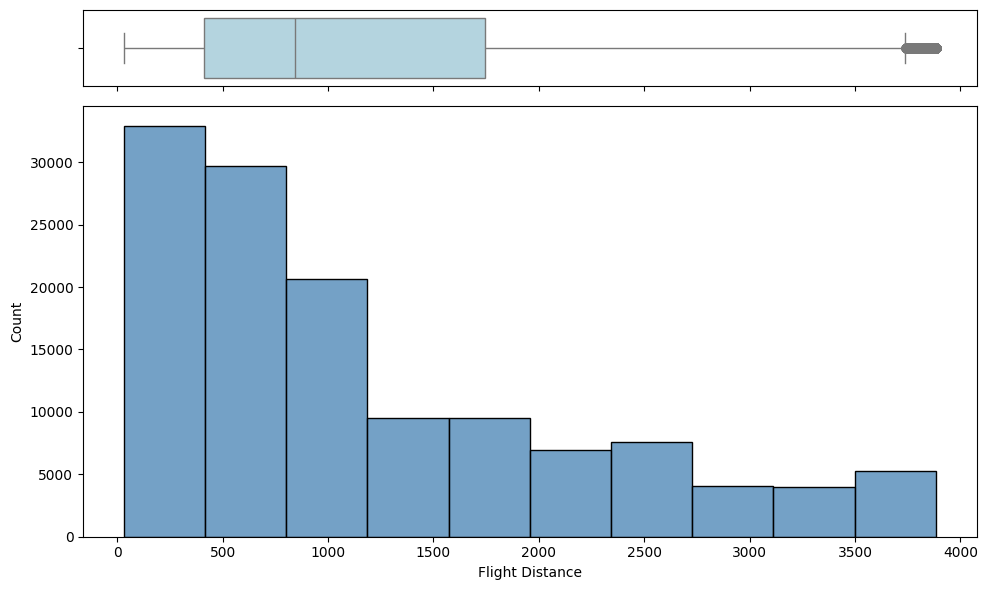

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ['Arrival Delay in Minutes', 'Departure Delay in Minutes','Flight Distance']
for col in cols_to_plot:
    filtered_train = train[train[col] > 0] # do có quá nhiều dữ liệu ở giá trị 0 nên em sẽ loại bỏ 0 để dễ nhìn các giá trị còn lại
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))
    sns.boxplot(x=train[col], ax=ax_box, color='lightblue')
    sns.histplot(data=filtered_train, x=col, ax=ax_hist, bins=10, color='steelblue')
    plt.tight_layout()
    plt.show()

Function `trans_binary_features` dùng để chuyển đổi các cột có 2 giá trị thành dạng `Binary (0,1)`  bằng vòng lập `For` :
- biến `target_mapping` là một `dictionary` dùng để lưu trữ tên cột và một giá trị trong cột
- function hoạt động theo cách sau: tạo một df mới --> chạy vòng lặp để lấy 2 giá trị (tên cột và dữ liệu trong cột) --> dùng hàm `if` để xét các cột cần chuyển đổi trong `df_ex` --> sau đó chuyển kiểu và xử lý đầu vào (gán lại kiểu dữ liệu, xóa bỏ khoảng trắng trước và sau) --> gán lại kết quả thành giá trị `int`

In [26]:
def trans_binary_features(df,mapping):
    df_ex = df.copy()
    for col, target_val in mapping.items():
        if col in df_ex.columns:
            df_ex[col] = (df_ex[col].astype(str).str.strip() == target_val).astype(int)
    return df_ex

In [27]:
target_mapping ={
    'Gender': 'Female',
    'Customer Type': 'Loyal Customer',
    'Type of Travel': 'Type of Travel',
    'satisfaction': 'satisfied'
}
df_second = trans_binary_features(df_second,target_mapping)
df_second

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,1,50-59,0,Eco,Very Short,5,4,3,4,...,5,5,5,5,2,5,5,Very delayed,Very delayed,1
1,1,1,30-39,0,Business,Long,1,1,3,1,...,4,4,4,4,3,4,5,On time,On time,1
2,0,0,20-29,0,Eco,Very Short,2,0,2,4,...,2,4,1,3,2,2,2,On time,On time,0
3,0,1,40-49,0,Business,Long,0,0,0,2,...,1,1,1,1,3,1,4,On time,Slightly delayed,1
4,1,1,40-49,0,Eco,Medium,2,3,4,3,...,2,2,2,2,4,2,4,On time,Delayed,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,1,0,20-29,0,Eco,Very Short,2,1,2,3,...,2,3,1,4,2,3,2,Slightly delayed,On time,0
129876,0,1,40-49,0,Business,Long,4,4,4,4,...,5,5,5,5,5,5,4,On time,On time,1
129877,0,0,30-39,0,Business,Long,1,1,1,3,...,4,3,2,4,5,5,4,Slightly delayed,Slightly delayed,0
129878,1,0,20-29,0,Eco,Medium,1,1,1,5,...,1,4,5,1,5,4,1,On time,On time,0


In [28]:
target_mapping ={
    'Gender': 'Female',
    'Customer Type': 'Loyal Customer',
    'Type of Travel': 'Type of Travel',
    'satisfaction': 'satisfied'
}
train = trans_binary_features(train,target_mapping)
train

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,1,52,0,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,1
1,1,1,36,0,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,1
2,0,0,20,0,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,0
3,0,1,44,0,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,1
4,1,1,49,0,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,1,0,23,0,Eco,192,2,1,2,3,...,2,3,1,4,2,3,2,3,0.0,0
129876,0,1,49,0,Business,2347,4,4,4,4,...,5,5,5,5,5,5,4,0,0.0,1
129877,0,0,30,0,Business,1995,1,1,1,3,...,4,3,2,4,5,5,4,7,14.0,0
129878,1,0,22,0,Eco,1000,1,1,1,5,...,1,4,5,1,5,4,1,0,0.0,0


In [29]:
y_one = train['satisfaction']
train = train.drop(columns=['satisfaction'])

In [30]:
y_second = df_second['satisfaction']
df_second = df_second.drop(columns='satisfaction')

### 2. Chuẩn hóa & Tiền xử lý dữ liệu


Do các bước xử lý tương tự model `Neural Network` trước đó em đã trình bày, nên giờ em sử dụng hàm `scaled_onehoted_funtion` mà em đã tạo dùng cho báo cáo này 

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder


Để model không bỏ qua các giá trị, cũng như sự ảnh hưởng của lớp `Class`. Tại đây e dùng `OrdinalEncoder` để tạo thứ tự từ `Eco` -> `Business` 

In [32]:
thu_tu_class = ['Eco', 'Eco Plus', 'Business']
class_encoder = OrdinalEncoder(categories=[thu_tu_class])
train['Class'] = class_encoder.fit_transform(train[['Class']])
df_second['Class'] = class_encoder.fit_transform(df_second[['Class']])

In [33]:
def scaled_onehoted_funtion(df):
    df_one = df.copy()

    numeric_col = df_one.select_dtypes(['int64','float']).columns.tolist()
    binary_features = ['Gender','Customer Type','Type of Travel']
    numeric_features= [col for col in numeric_col if col not in binary_features]
    categorical_features = df_one.select_dtypes(include=['string']).columns.tolist()

    preprocessor = ColumnTransformer(transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features), 
        ('binary', 'passthrough', binary_features)
    ])
    train_features_scaled = preprocessor.fit_transform(df_one)
    X_train = pd.DataFrame(train_features_scaled, 
                            index=df_one.index, 
                            columns=preprocessor.get_feature_names_out())
    return X_train

In [34]:
X_train= scaled_onehoted_funtion(train)
df_final_one = X_train.copy()
df_final_one

,num__Age,num__Class,num__Flight Distance,num__Inflight wifi service,num__Departure/Arrival time convenient,num__Ease of Online booking,num__Gate location,num__Food and drink,num__Online boarding,num__Seat comfort,...,num__Leg room service,num__Baggage handling,num__Checkin service,num__Inflight service,num__Cleanliness,num__Departure Delay in Minutes,num__Arrival Delay in Minutes,binary__Gender,binary__Customer Type,binary__Type of Travel
0,0.576923,0.0,0.033480,1.0,0.8,0.6,0.8,0.6,0.8,0.6,...,1.0,1.00,0.4,1.0,1.0,0.277778,0.241758,1.0,1.0,0.0
1,0.371795,1.0,0.735012,0.2,0.2,0.6,0.2,1.0,0.8,1.0,...,0.8,0.75,0.6,0.8,1.0,0.000000,0.000000,1.0,1.0,0.0
2,0.166667,0.0,0.041786,0.4,0.0,0.4,0.8,0.4,0.4,0.4,...,0.2,0.50,0.4,0.4,0.4,0.000000,0.000000,0.0,0.0,0.0
3,0.474359,1.0,0.868414,0.0,0.0,0.0,0.4,0.6,0.8,0.8,...,0.2,0.00,0.6,0.2,0.8,0.000000,0.032967,0.0,1.0,0.0
4,0.538462,0.0,0.298728,0.4,0.6,0.8,0.6,0.8,0.2,0.4,...,0.4,0.25,0.8,0.4,0.8,0.000000,0.109890,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,0.205128,0.0,0.041786,0.4,0.2,0.4,0.6,0.4,0.4,0.4,...,0.2,0.75,0.4,0.6,0.4,0.016667,0.000000,1.0,0.0,0.0
129876,0.538462,1.0,0.601090,0.8,0.8,0.8,0.8,0.4,0.8,1.0,...,1.0,1.00,1.0,1.0,0.8,0.000000,0.000000,0.0,1.0,0.0
129877,0.294872,1.0,0.509733,0.2,0.2,0.2,0.6,0.8,0.2,1.0,...,0.4,0.75,1.0,1.0,0.8,0.038889,0.076923,0.0,0.0,0.0
129878,0.192308,0.0,0.251492,0.2,0.2,0.2,1.0,0.2,0.2,0.2,...,1.0,0.00,1.0,0.8,0.2,0.000000,0.000000,1.0,0.0,0.0


In [35]:
thu_tu_class = ['On time', 'Slightly delayed', 'Delayed', 'Very delayed']
# thu_tu_class = ['Very delayed','Delayed', 'Slightly delayed','On time' ]
# Khởi tạo cỗ máy encoder cho Class
class_encoder = OrdinalEncoder(categories=[thu_tu_class])

# Áp dụng vào DataFrame (lưu ý phải truyền vào list 2 chiều [['Class']])
df_second['Arrival Delay in Minutes'] = class_encoder.fit_transform(df_second[['Arrival Delay in Minutes']])
df_second['Departure Delay in Minutes'] = class_encoder.fit_transform(df_second[['Departure Delay in Minutes']])

In [36]:
df_final_second= scaled_onehoted_funtion(df_second)
df_final_second

,num__Class,num__Inflight wifi service,num__Departure/Arrival time convenient,num__Ease of Online booking,num__Gate location,num__Food and drink,num__Online boarding,num__Seat comfort,num__Inflight entertainment,num__On-board service,...,cat__Age_50-59,cat__Age_60+,cat__Age_<20,cat__Flight Distance_Long,cat__Flight Distance_Medium,cat__Flight Distance_Short,cat__Flight Distance_Very Short,binary__Gender,binary__Customer Type,binary__Type of Travel
0,0.0,1.0,0.8,0.6,0.8,0.6,0.8,0.6,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,1.0,0.2,0.2,0.6,0.2,1.0,0.8,1.0,0.8,0.8,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.4,0.0,0.4,0.8,0.4,0.4,0.4,0.4,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.4,0.6,0.8,0.8,0.2,0.2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.4,0.6,0.8,0.6,0.8,0.2,0.4,0.4,0.4,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,0.0,0.4,0.2,0.4,0.6,0.4,0.4,0.4,0.4,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
129876,1.0,0.8,0.8,0.8,0.8,0.4,0.8,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
129877,1.0,0.2,0.2,0.2,0.6,0.8,0.2,1.0,0.8,0.6,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
129878,0.0,0.2,0.2,0.2,1.0,0.2,0.2,0.2,0.2,0.8,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### 3. Train và Tinh chỉnh mô hình


##### 3.1: df_final_one

Nhóm em tạo model KMeans với 3 thông số điều chỉnh đó là:
- `n_clusters`: Số nhóm muốn KMeans dự đoán
- `random_state`: cố định lại dữ liệu, để thử nghiệm các thông số mang lại hiệu quả thật sự
- `n_init`: số vòng lập

In [37]:
from sklearn.cluster import KMeans
k = 2
kmeans_one = KMeans(n_clusters=2, random_state=42, n_init=20)
y_kmeans_one = kmeans_one.fit_predict(df_final_one)


Tại đây Nhóm em sử dụng ma trận tương quan để tìm ra các cột có độ mật thiết với `target` nhất để vẽ biểu đồ trực quang.

In [38]:
df_one_transformed = pd.concat([df_final_one,y_one],axis=1)
corr_matrix = df_one_transformed.corr()

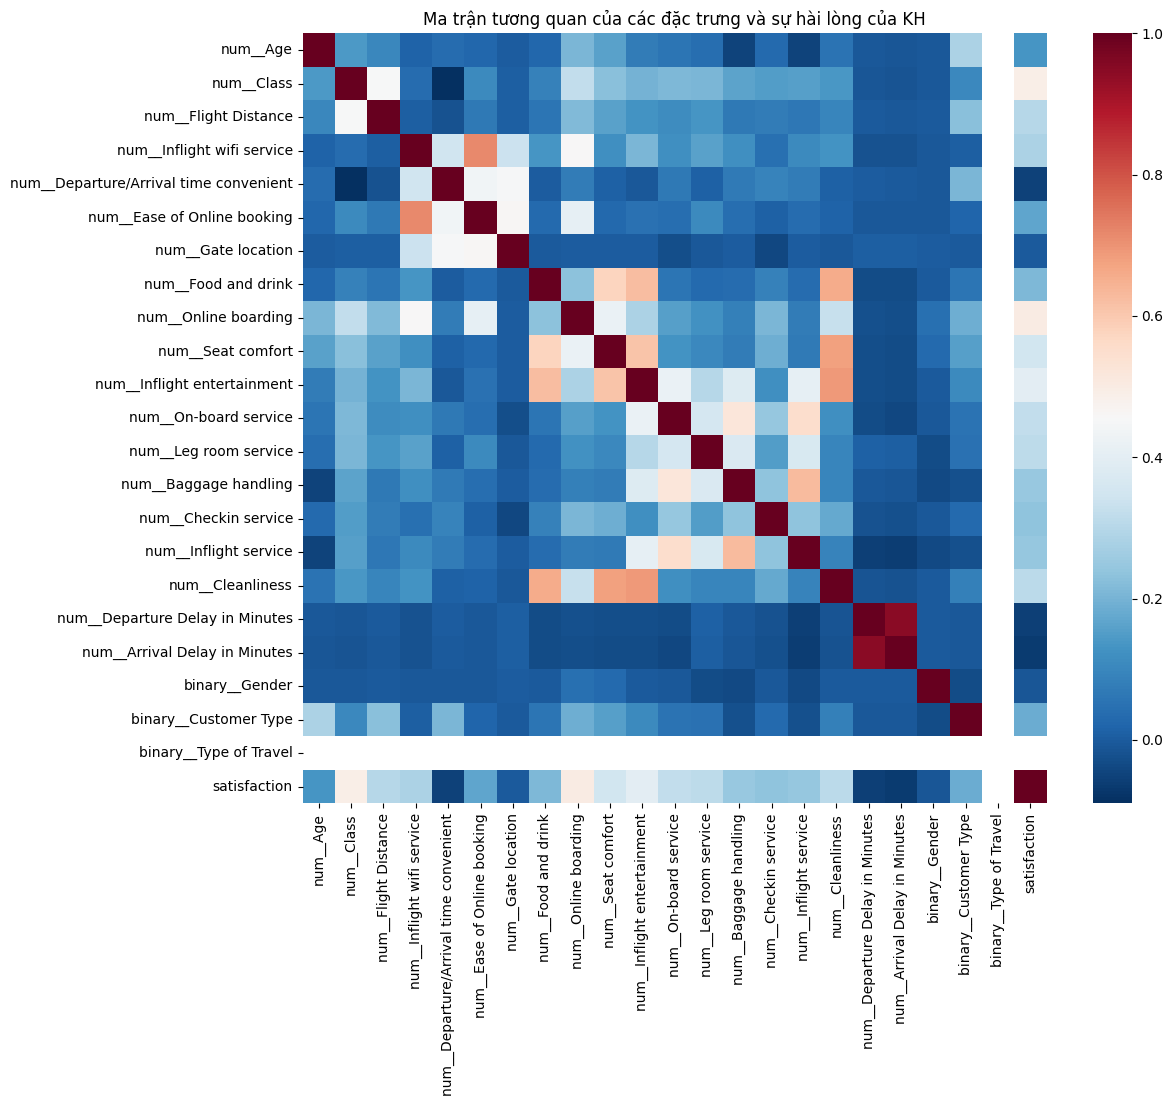

In [39]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,cmap= 'RdBu_r')
plt.title('Ma trận tương quan của các đặc trưng và sự hài lòng của KH')
plt.show()

In [40]:
top_correlations = corr_matrix['satisfaction'].abs().sort_values(ascending= False)
top_correlations.head(5)

satisfaction                   1.000000
num__Online boarding           0.501749
num__Class                     0.492947
num__Inflight entertainment    0.398234
num__Seat comfort              0.348829
Name: satisfaction, dtype: float64

In [41]:
df_one = train.copy()

Do 2 cột dữ liệu được chọn để trực quan dữ liệu ở dạng nhóm (1-5) nên dùng biểu đồ `scatter` không thể hiện hết được những điểm dữ liệu nằm đè lên nhau

Text(0.5, 1.0, 'kmeans')

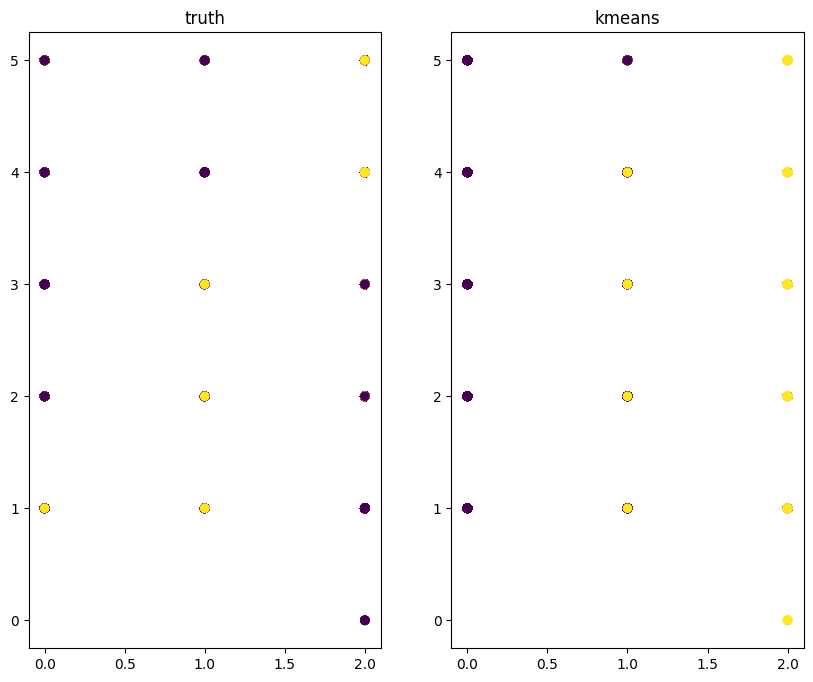

In [42]:
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.scatter(df_one['Class'], df_one['On-board service'], c=y_one)
plt.title('truth')
plt.subplot(1, 2, 2)
plt.scatter(df_one['Class'],df_one['On-board service'], c=y_kmeans_one)
plt.title('kmeans')

Tại đây nhóm sữ dụng biểu đồ `Stripplot` để thể hiện toàn bộ dữ liệu trong từng điểm mà biểu đồ `Scatter` không làm được

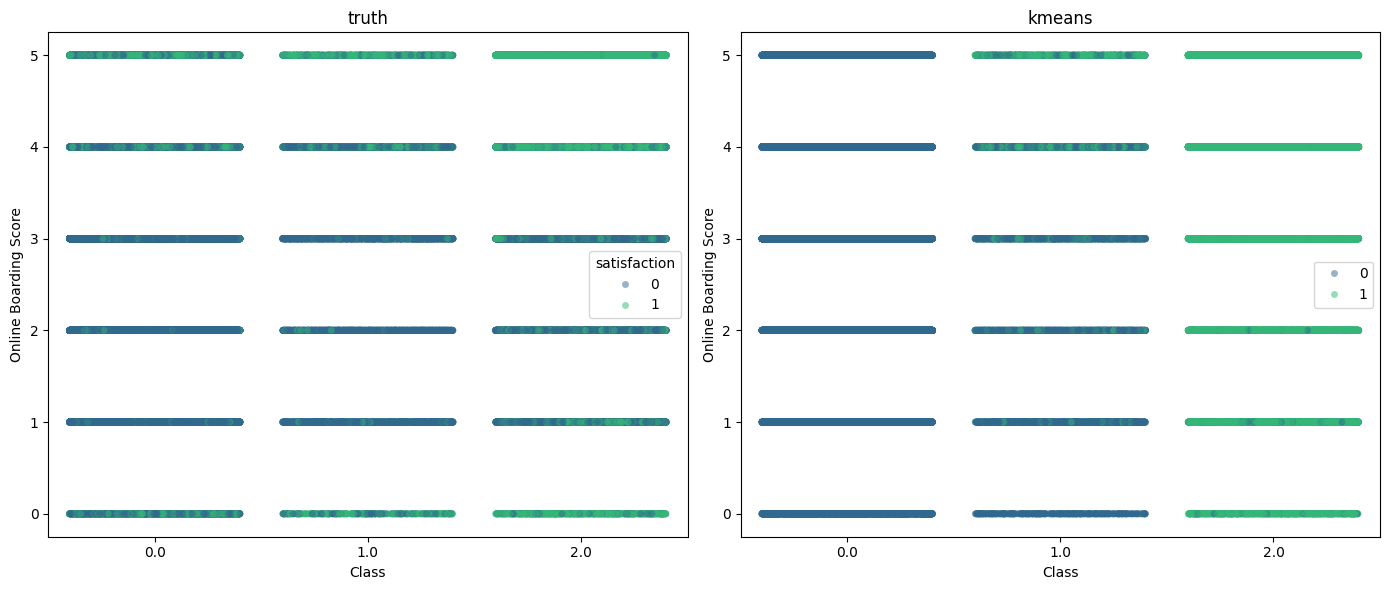

In [43]:
fig = plt.figure(figsize=(14, 6))
# Biểu đồ 1: Thực tế (Truth)
plt.subplot(1, 2, 1)
sns.stripplot(
    data=df_one,               # Dùng DataFrame gốc (đã xử lý số dòng khớp với y)
    x='Class',                 # Trục X là Hạng ghế (dạng chữ cho dễ đọc)
    y='Online boarding',       # Trục Y là Điểm Online Boarding
    hue=y_one,                 # Tô màu theo đáp án thật
    jitter=0.4,                # Độ rung lắc tản đều các điểm
    alpha=0.5,                 # Làm trong suốt để thấy phần bị đè
    palette='viridis'
)
plt.title('truth')
plt.ylabel('Online Boarding Score')

# Biểu đồ 2: K-Means dự đoán
plt.subplot(1, 2, 2)
sns.stripplot(
    data=df_one, 
    x='Class', 
    y='Online boarding', 
    hue=y_kmeans_one,          # Tô màu theo K-Means dự đoán
    jitter=0.4, 
    alpha=0.5, 
    palette='viridis'
)
plt.title('kmeans')
plt.ylabel('Online Boarding Score')

plt.tight_layout()
plt.show()

Ta thấy được ở dữ liệu thật của biểu đồ truth:
- **Sự đan xen phức tạp:** Các điểm Xanh lá (Hài lòng - 1) và Xanh dương (Không hài lòng - 0) chồng chéo cực lên nhau ở gần như mọi hạng vé và mọi mức điểm.  
- **Biểu đồ này phản ánh đúng thực tế kinh doanh:** Sự hài lòng của hành khách rất phi tuyến tính, mặc dù điểm Boarding cao (4, 5) có vẻ tập trung nhiều màu xanh lá hơn, nhưng vẫn có rất nhiều người cho điểm 4, 5 mà vẫn không hài lòng (màu xanh dương).  
-> *Không có một ranh giới thẳng nào để chia đôi hai nhóm này.*  
----
Biểu đồ KMeans:  
Sự cứng nhắc của thuật toán: `K-Means` phân cụm thuần túy dựa trên khoảng cách hình học Euclidean. Nó chỉ đơn giản là tìm trung điểm và lấy dao "cắt" đồ thị ra thành các khối vuông vức

Mô hình `KMeans` đưa ra 2 kết quả `ARI` và `DBI` không thật sự lý tưởng để sử dụng model này cho bộ dữ liệu bị chồng lấn dữ liệu nặng như vậy.

In [44]:
from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(y_one, y_kmeans_one)

print(f"Chỉ số ARI của mô hình: {ari_score:.4f}")

Chỉ số ARI của mô hình: 0.2533


In [45]:
from sklearn.metrics import davies_bouldin_score
db_index = davies_bouldin_score(df_final_one, y_kmeans_one)

print(f"Chỉ số Davies-Bouldin (DBI): {db_index:.4f}")

Chỉ số Davies-Bouldin (DBI): 2.3515


##### 3.2: df_final_second

In [46]:
from sklearn.cluster import KMeans
k = 2
kmeans_second = KMeans(n_clusters=2, random_state=42, n_init=20)
y_kmeans_second = kmeans_one.fit_predict(df_final_second)


In [47]:
df_one_transformed = pd.concat([df_final_second,y_second],axis=1)
corr_matrix = df_one_transformed.corr()

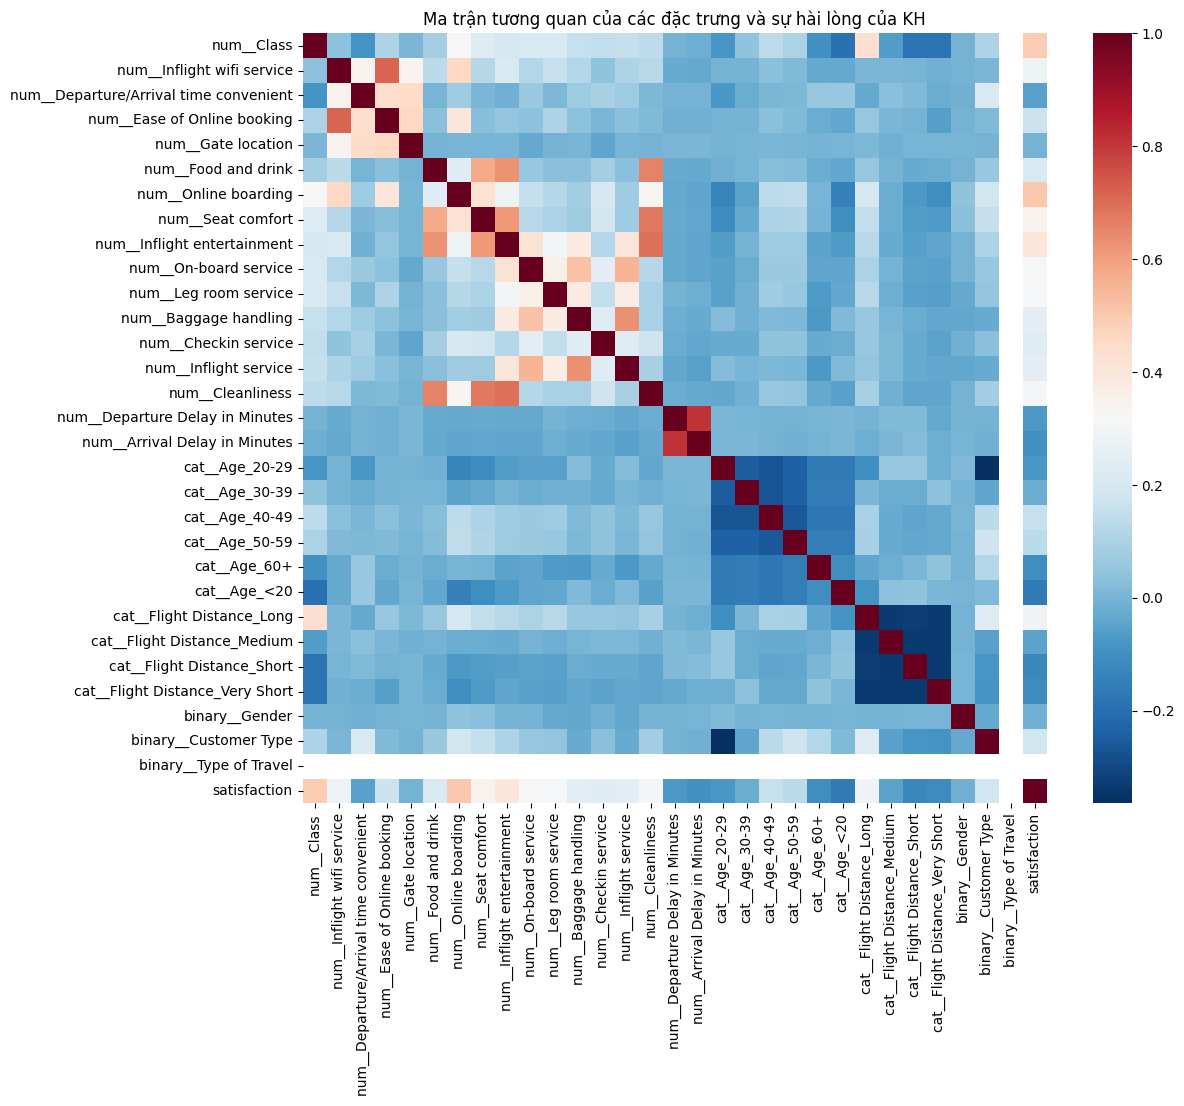

In [48]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,cmap= 'RdBu_r')
plt.title('Ma trận tương quan của các đặc trưng và sự hài lòng của KH')
plt.show()

In [49]:
top_correlations = corr_matrix['satisfaction'].abs().sort_values(ascending= False)
top_correlations.head(5)

satisfaction                   1.000000
num__Online boarding           0.501749
num__Class                     0.492947
num__Inflight entertainment    0.398234
num__Seat comfort              0.348829
Name: satisfaction, dtype: float64

Text(0.5, 1.0, 'kmeans')

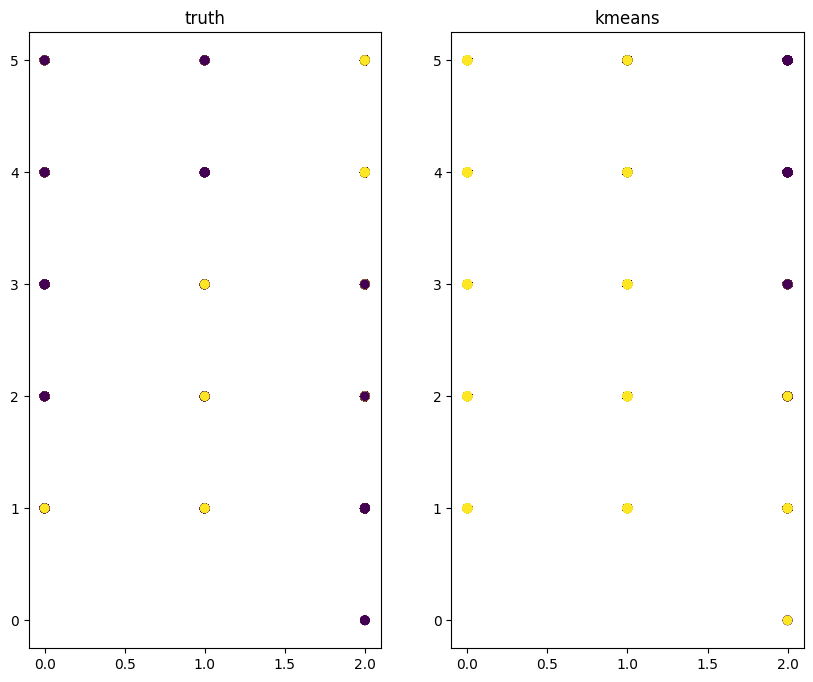

In [50]:
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.scatter(df_second['Class'], df_second['On-board service'], c=y_second)
plt.title('truth')
plt.subplot(1, 2, 2)
plt.scatter(df_second['Class'],df_second['On-board service'], c=y_kmeans_second)
plt.title('kmeans')

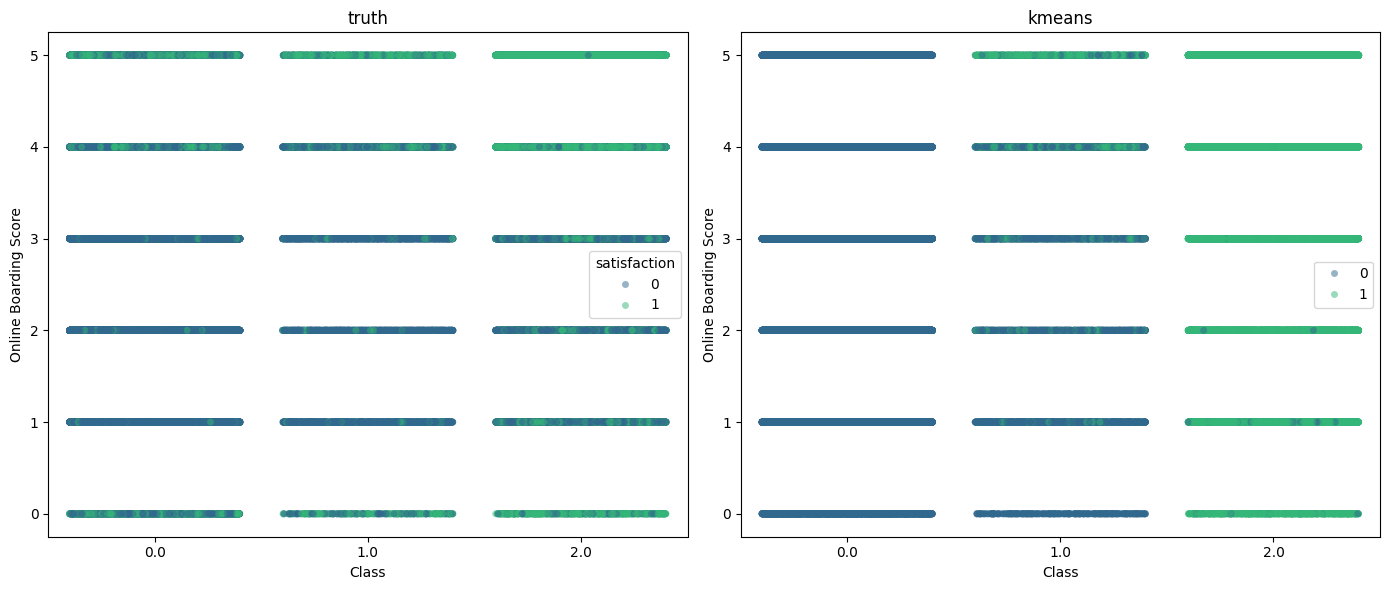

In [51]:
fig = plt.figure(figsize=(14, 6))
# Biểu đồ 1: Thực tế (Truth)
plt.subplot(1, 2, 1)
sns.stripplot(
    data=df_one,               # Dùng DataFrame gốc (đã xử lý số dòng khớp với y)
    x='Class',                 # Trục X là Hạng ghế (dạng chữ cho dễ đọc)
    y='Online boarding',       # Trục Y là Điểm Online Boarding
    hue=y_one,                 # Tô màu theo đáp án thật
    jitter=0.4,                # Độ rung lắc tản đều các điểm
    alpha=0.5,                 # Làm trong suốt để thấy phần bị đè
    palette='viridis'
)
plt.title('truth')
plt.ylabel('Online Boarding Score')

# Biểu đồ 2: K-Means dự đoán
plt.subplot(1, 2, 2)
sns.stripplot(
    data=df_one, 
    x='Class', 
    y='Online boarding', 
    hue=y_kmeans_one,          # Tô màu theo K-Means dự đoán
    jitter=0.4, 
    alpha=0.5, 
    palette='viridis'
)
plt.title('kmeans')
plt.ylabel('Online Boarding Score')

plt.tight_layout()
plt.show()

Ở bộ dữ liệu `df_second` được xử lý nhiều hơn bộ `df_one`  
- sau khi đã xử lý các cột dữ liệu quan trọng và cũng như đã gom nhóm các cột như `Departure`, `Class`, `Arrival`.

Thì model cho ra các chỉ số của `ARI` tăng lên một ít, nhưng đồng thời `DBI` cũng tăng theo 

In [52]:
from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(y_second, y_kmeans_second)

print(f"Chỉ số ARI của mô hình: {ari_score:.4f}")

Chỉ số ARI của mô hình: 0.3173


In [53]:

from sklearn.metrics import davies_bouldin_score
db_index = davies_bouldin_score(df_final_second, y_kmeans_second)

print(f"Chỉ số Davies-Bouldin (DBI): {db_index:.4f}")

Chỉ số Davies-Bouldin (DBI): 3.0024


### 4. Đánh giá kết quả

Thông qua những chỉ số đánh giá model Clustering tại đây là `ARI` và `DBI`

Nhóm em thông qua biểu đồ phân bố dữ liệu và các thông số phản ảnh model, ta nhận thấy `KMeans` hoạt động **không hiệu quả** với bộ dữ liệu bị chồng lấp, đan xen giữa các lớp.

### 5. Tóm tắt mô hình

|Tên model|Thông số model|ARI|DBI|
|-----------------:|----------------:|-----------------:|-----------------:|
|model_1|n_clusters=2, random_state=42, n_init=20|0.2533|2.3515|
|model_2|n_clusters=2, random_state=42, n_init=20|0.3173|3.0024|

## B. GMM (Gaussian Mixture Model)

Đây là Model tiếp theo nhóm em dùng để xử lý bộ dữ liệu đặc thù là chồng lấn và đan xen.  
Đó là Model `GMM` dùng phân phối `Gauss` để tính xác suất mà các điểm dữ liệu có thể thuộc về của từng phân nhóm

Ở model này nhóm sẽ sử dụng lại các `DataFrame` mà đã được xử lý ở model `Kmeans`
***
|Tên Dataframe| Đặc tính|
|-----------------:|----------------:|
| df_one | đã tiền xử lý, chưa scaler và onehot |
| y_one | biến target của df_one|
| df_final_one| dữ liệu dùng để train model |
| df_second | đã tiền xử lý, chưa scaler và onehot |
| y_second | biến target của df_second |
| df_final_second | dữ liệu dùng để train model |

### 3. Train và tinh chỉnh mô hình

#### 3.1 df_final_one

Model GMM:  
1. **n_components**: số nhóm mà GMM cần phân phối, tại bộ dữ liệu này với 2 biến của cột target nên mặc định sẽ là 2 
2. **covariance_type**: quyết định hình dáng và độ nghiên của các cụm dữ liệu, tại đây với bộ dữ liệu chồng lấn thì tham số này nên sử dụng mặc định là `full` mô hình sẽ cho phép các cụm uốn dẻo thành mọi hình thù bầu dục với mọi kích thước và góc nghiêng khác nhau.  
3. **tol** (thường được đặt =$0.001$ ($10^{-3}$)): sau một bước lặp, mức độ cải thiện của mô hình bé hơn tol, mô hình sẽ tự động dừng sớm để tiết kiệm thời gian tính toán.
4. **n_init**: giống như số lần lập lại của model  
5. **max_iter**: Số bước di chuyển tối đa cho mỗi lần chạy vòng lặp 
6. **init_params**: cung cấp các chiến lược cho model lựa chọn `k-means++` sẽ tính toán toán học để rải các tâm cụm ban đầu ra càng xa nhau càng tốt 
---
- Ở bộ dữ liệu có điểm dữ liệu đan xen và chồng lấp thì tham số `full` của biến `covariance_type` là thích hợp nhất  
- Một phát hiện là khi dùng với biến là `spherical` các công cụ đánh giá như `ARI` và `DBI` cho ra kết quả tốt hơn là biến `full` nguyên nhân mà nhóm em đưa ra cho việc này là do:  
Các tham số khác như `full` hay `tied` cố gắng học cả hướng và mối tương quan giữa các biến  
       - `full`: Cần học $O(n^2)$ tham số cho mỗi cụm (với $n$ là số features)  
       - `spherical`: Chỉ cần học 1 tham số duy nhất cho phương sai của mỗi cụm.  
-> Vì bộ dữ liệu Airline có số lượng đặc trưng khá lớn (hơn 20 đặc trưng), việc dùng `full` dễ dẫn đến việc mô hình "cố quá mức" để bao phủ các điểm nhiễu, làm sai lệch ranh giới cụm. `spherical` đóng vai trò như một bộ lọc, giữ cho các cụm đơn giản và tổng quát hóa tốt hơn, dẫn đến điểm ARI cao hơn khi so với nhãn thực tế.

In [54]:
# from sklearn.mixture import GaussianMixture
# n = 2
# cov_type = 'spherical'
# tol= 0.000001

# GMM_model_one = GaussianMixture(n_components=n,
#                            covariance_type=cov_type,
#                            tol=tol,
#                            random_state=42,
#                            n_init=25,
#                            max_iter= 100,
#                            init_params= 'k-means++')
# y_GMM = GMM_model_one.fit_predict(df_final_one)

In [55]:
from sklearn.mixture import GaussianMixture

GMM_model_one = GaussianMixture(n_components=2,
                           covariance_type='full',
                           tol= 0.00001,
                           random_state=42,
                           n_init=25,
                           max_iter= 100,
                           init_params= 'k-means++')
y_GMM = GMM_model_one.fit_predict(df_final_one)

Text(0.5, 1.0, 'kmeans')

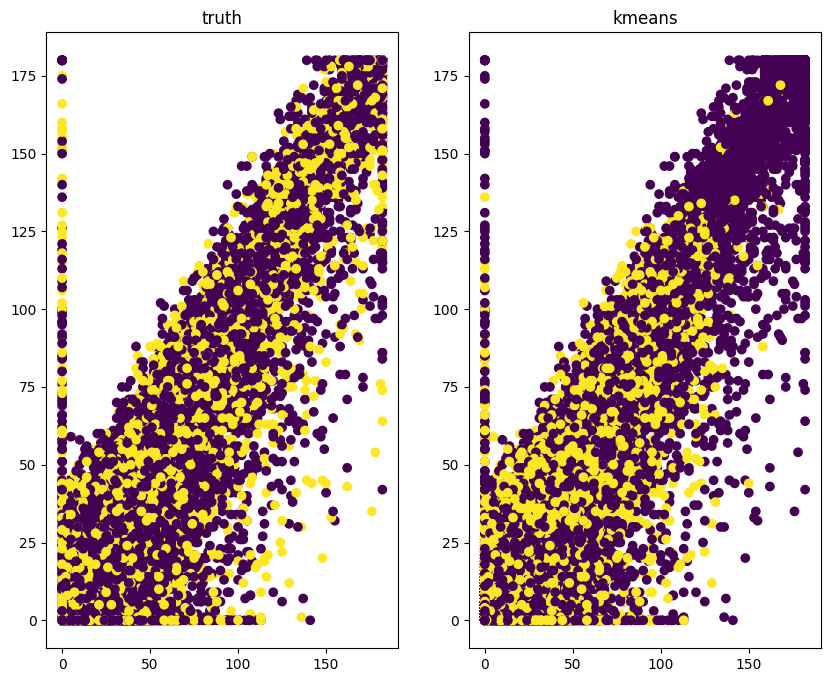

In [56]:
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.scatter(df_one['Arrival Delay in Minutes'], df_one['Departure Delay in Minutes'], c=y_one)
plt.title('truth')
plt.subplot(1, 2, 2)
plt.scatter(df_one['Arrival Delay in Minutes'], df_one['Departure Delay in Minutes'], c=y_GMM)
plt.title('kmeans')

In [57]:
from sklearn.metrics import adjusted_rand_score
ari_score = adjusted_rand_score(y_one, y_GMM)
print(f"Chỉ số ARI của mô hình: {ari_score:.4f}")

Chỉ số ARI của mô hình: 0.1292


In [58]:
from sklearn.metrics import davies_bouldin_score
db_index = davies_bouldin_score(df_final_one, y_GMM)
print(f"Chỉ số Davies-Bouldin (DBI): {db_index:.4f}")

Chỉ số Davies-Bouldin (DBI): 3.6220


#### 3.2 df_final_second

In [59]:
from sklearn.mixture import GaussianMixture

GMM_model_2 = GaussianMixture(n_components=2,
                           covariance_type='spherical',
                           tol=0.000001,
                           random_state=42,
                           n_init=25,
                           max_iter= 100,
                           init_params= 'k-means++')
y_GMM_second = GMM_model_2.fit_predict(df_final_second)

Text(0.5, 1.0, 'GMM')

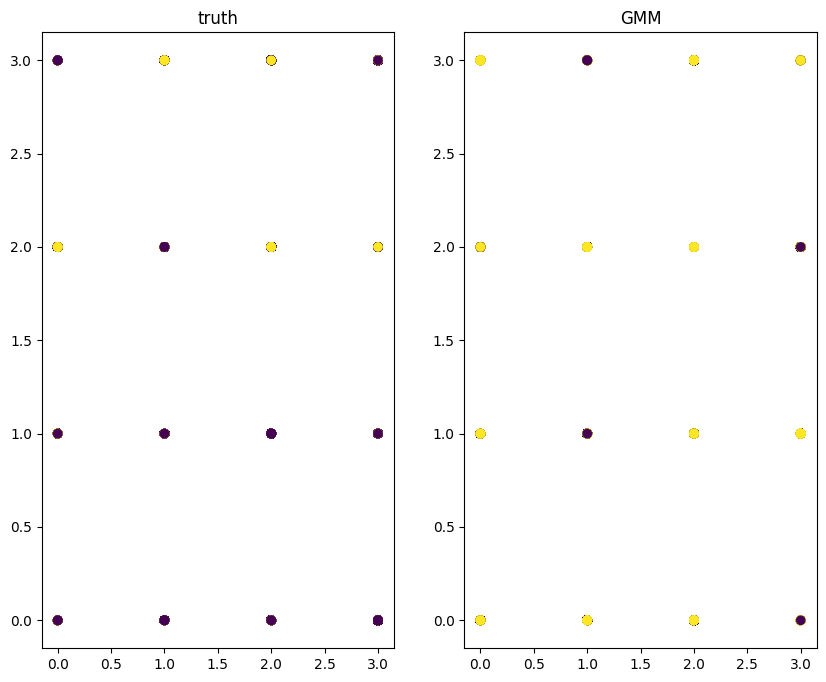

In [60]:
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.scatter(df_second['Arrival Delay in Minutes'], df_second['Departure Delay in Minutes'], c=y_second)
plt.title('truth')
plt.subplot(1, 2, 2)
plt.scatter(df_second['Arrival Delay in Minutes'], df_second['Departure Delay in Minutes'], c=y_GMM_second)
plt.title('GMM')

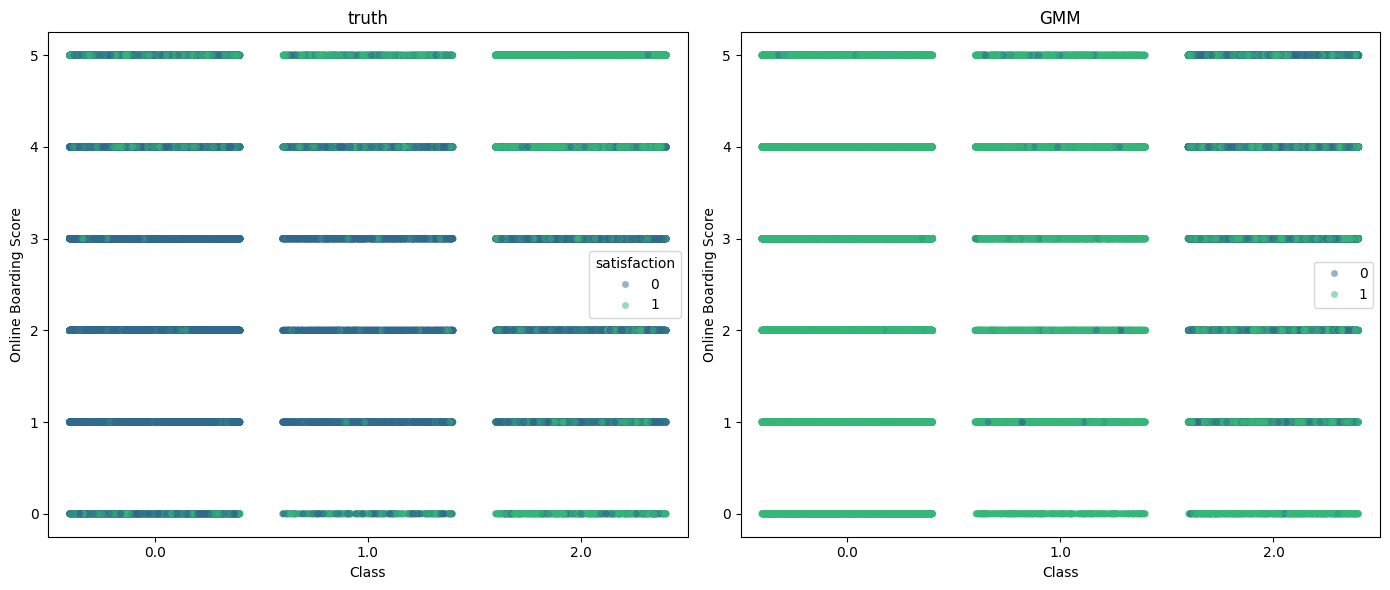

In [61]:
fig = plt.figure(figsize=(14, 6))
# Biểu đồ 1: Thực tế (Truth)
plt.subplot(1, 2, 1)
sns.stripplot(
    data=df_second,               # Dùng DataFrame gốc (đã xử lý số dòng khớp với y)
    x='Class',                 # Trục X là Hạng ghế (dạng chữ cho dễ đọc)
    y='Online boarding',       # Trục Y là Điểm Online Boarding
    hue=y_second,                 # Tô màu theo đáp án thật
    jitter=0.4,                # Độ rung lắc tản đều các điểm
    alpha=0.5,                 # Làm trong suốt để thấy phần bị đè
    palette='viridis'
)
plt.title('truth')
plt.ylabel('Online Boarding Score')

# Biểu đồ 2: K-Means dự đoán
plt.subplot(1, 2, 2)
sns.stripplot(
    data=df_second, 
    x='Class', 
    y='Online boarding', 
    hue=y_GMM_second,          # Tô màu theo K-Means dự đoán
    jitter=0.4, 
    alpha=0.5, 
    palette='viridis'
)
plt.title('GMM')
plt.ylabel('Online Boarding Score')

plt.tight_layout()
plt.show()

Sự gò ép của `GMM` (Biểu đồ GMM)  
Phân chia quá máy móc: Thuật toán GMM dường như đã đưa ra một quyết định cực đoan để chia cắt dữ liệu:

1. Ở hai hạng ghế đầu tiên (Class ~0.0 và ~1.0): GMM gần như quét sạch và gán toàn bộ khách hàng vào cụm Xanh dương (Không hài lòng). Nó đã bỏ lọt hoàn toàn những khách hàng Xanh lá thực sự tồn tại ở khu vực này.

2. Ở hạng ghế cao nhất (Class ~2.0): Nó chia cắt theo chiều ngang. Những ai có điểm Boarding thấp (0, 1, 2) bị gán là Xanh dương, còn điểm cao (3, 4, 5) thì được gán là Xanh lá.

`GMM` đã tạo ra các khối phân bố gọn gàng hơn, nhưng nó đã đơn giản hóa thái quá hành vi của khách hàng, dẫn đến việc dự đoán sai rất nhiều (ARI khó có thể đạt mức tuyệt đối).

In [62]:
from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(y_second, y_GMM_second)

print(f"Chỉ số ARI của mô hình: {ari_score:.4f}")

Chỉ số ARI của mô hình: 0.1204


In [63]:
from sklearn.metrics import davies_bouldin_score
db_index = davies_bouldin_score(df_final_second, y_GMM_second)

print(f"Chỉ số Davies-Bouldin (DBI): {db_index:.4f}")

Chỉ số Davies-Bouldin (DBI): 2.4960


#### 3.3 Xử lý lại dữ liệu của df_final_second

Chọn các loại dữ liệu đánh giá của df_final_second

In [64]:
import pandas as pd
# 1. Liệt kê chính xác 14 cột đánh giá dịch vụ (thang 0-5)
rating_columns = df_final_second.columns
rating_columns = rating_columns[1:15]
df_final_second['Average_Rating'] = df_final_second[rating_columns].mean(axis=1)
df_final_second = df_final_second.drop(columns=rating_columns)

In [65]:
df_final_second

,num__Class,num__Departure Delay in Minutes,num__Arrival Delay in Minutes,cat__Age_20-29,cat__Age_30-39,cat__Age_40-49,cat__Age_50-59,cat__Age_60+,cat__Age_<20,cat__Flight Distance_Long,cat__Flight Distance_Medium,cat__Flight Distance_Short,cat__Flight Distance_Very Short,binary__Gender,binary__Customer Type,binary__Type of Travel,Average_Rating
0,0.0,1.000000,1.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.828571
1,1.0,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.682143
2,0.0,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.421429
3,1.0,0.000000,0.333333,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.342857
4,0.0,0.000000,0.666667,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.517857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,0.0,0.333333,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.439286
129876,1.0,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.871429
129877,1.0,0.333333,0.333333,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.610714
129878,0.0,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.442857


In [66]:
from sklearn.mixture import GaussianMixture

GMM_model_3 = GaussianMixture(n_components=2,
                           covariance_type='spherical',
                           tol=0.000001,
                           random_state=42,
                           n_init=20,
                           init_params= 'k-means++')
y_GMM_three = GMM_model_3.fit_predict(df_final_second)

In [67]:
from sklearn.metrics import adjusted_rand_score
ari_score = adjusted_rand_score(y_second, y_GMM_three)
print(f"Chỉ số ARI của mô hình: {ari_score:.4f}")

Chỉ số ARI của mô hình: 0.1143


In [68]:
from sklearn.metrics import davies_bouldin_score
db_index = davies_bouldin_score(df_final_second, y_GMM_three)
print(f"Chỉ số Davies-Bouldin (DBI): {db_index:.4f}")

Chỉ số Davies-Bouldin (DBI): 2.0783


Text(0.5, 1.0, 'GMM')

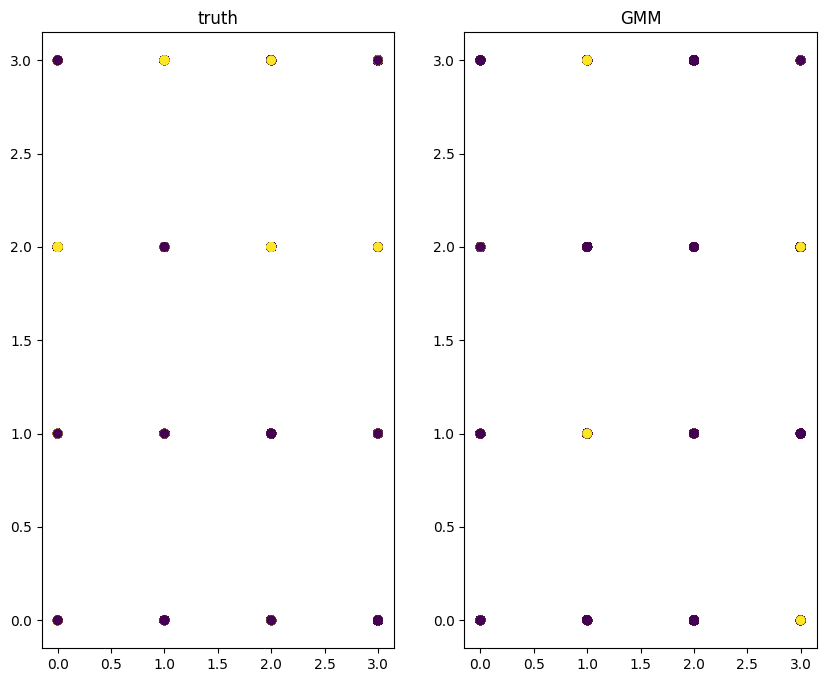

In [69]:
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.scatter(df_second['Arrival Delay in Minutes'], df_second['Departure Delay in Minutes'], c=y_second)
plt.title('truth')
plt.subplot(1, 2, 2)
plt.scatter(df_second['Arrival Delay in Minutes'], df_second['Departure Delay in Minutes'], c=y_GMM_three)
plt.title('GMM')

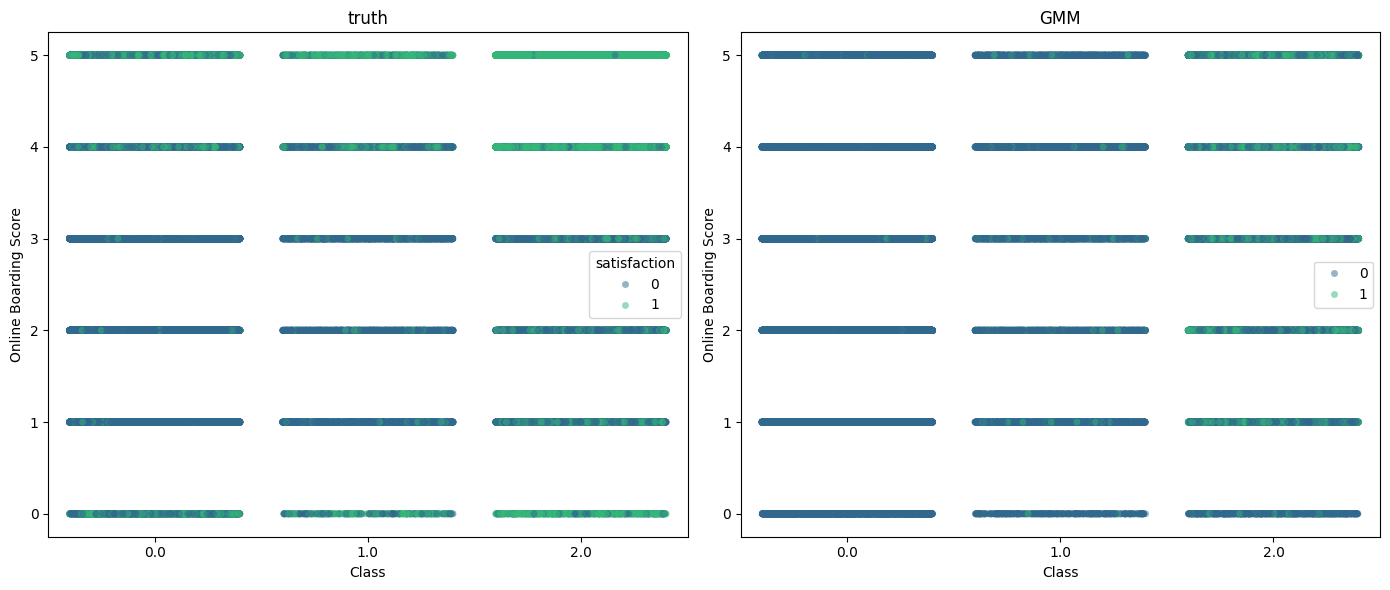

In [70]:
fig = plt.figure(figsize=(14, 6))
# Biểu đồ 1: Thực tế (Truth)
plt.subplot(1, 2, 1)
sns.stripplot(
    data=df_second,               # Dùng DataFrame gốc (đã xử lý số dòng khớp với y)
    x='Class',                 # Trục X là Hạng ghế (dạng chữ cho dễ đọc)
    y='Online boarding',       # Trục Y là Điểm Online Boarding
    hue=y_second,                 # Tô màu theo đáp án thật
    jitter=0.4,                # Độ rung lắc tản đều các điểm
    alpha=0.5,                 # Làm trong suốt để thấy phần bị đè
    palette='viridis'
)
plt.title('truth')
plt.ylabel('Online Boarding Score')

# Biểu đồ 2: K-Means dự đoán
plt.subplot(1, 2, 2)
sns.stripplot(
    data=df_second, 
    x='Class', 
    y='Online boarding', 
    hue=y_GMM_three,          # Tô màu theo K-Means dự đoán
    jitter=0.4, 
    alpha=0.5, 
    palette='viridis'
)
plt.title('GMM')
plt.ylabel('Online Boarding Score')

plt.tight_layout()
plt.show()

Thông qua biểu đồ trực quan ta thấy được `GMM` gần như là bất lực trong việc phân chia dữ liệu của 2 nhóm trên, khi mà bộ dữ liệu chỉ được gộp các giá trị trong từng cột.  
Phương pháp xử lý dữ liệu đầu vào này gần như không có tác dụng để giúp model chạy mượt mà hay là cho ra một kết quả tốt hơn.

### 4. Đánh giá

Thông qua số liệu mà `model GMM` cho ra ở 3 model với các cách xử lý dự liệu khác nhau như sau:  

| Tên Model |Thông số| Chỉ số ARI | Chỉ số DBI |
|-----------------:|----------------:|-----------------:|-----------------:|
| GMM_model_one |n_components=2, covariance_type='full', tol= 0.00001, random_state=42, n_init=25,max_iter= 100, init_params= 'k-means++'| 0.3748 | 2.2974 |
| GMM_model_second |n_components=2, covariance_type='spherical', tol=0.000001, random_state=42, n_init=25, max_iter= 100, init_params= 'k-means++'| 0.1204 | 2.4960 |
| GMM_model_second chạy lần 2 |n_components=2, covariance_type='spherical', tol=0.000001, random_state=42, n_init=20, init_params= 'k-means++'| 0.1143 | 2.0783 |

1. Với `GMM_model_one` sử dụng bộ dữ liệu `df_final_one` cho ta kết quả tốt và cũng như là khả quan nhất 3 bộ dữ liệu mà nhóm em đã test.  
2. Với `GMM_model_second` chạy lần 1: việc gom nhóm các cột `Age, Departure, Arrival` không mang đến tác dụng cho việc chạy model thông qua chỉ số `ARI` và `DBI` đánh giá.  
3. Cuối cùng `GMM_model_second` chạy lần 2 đã chứng minh điều mà vừa nói trên, khi bước cải tiến dữ liệu ở model này đó là giảm số chiều mà các nhóm đánh giá mang lại bằng cách tạo một cột total với giá trị là `mean` của toàn bộ cột dữ liệu đánh giá dịch vụ

Thông qua 2 model `Kmeans` và `GMM`. Nhóm em thấy được sự hạn chế của các model Clustering trong việc xử lý các bộ bộ dữ liệu có các điểm dữ liệu chồng lấn và đan xen phức tạp như bộ *Airline Passenger Satisfaction*.